In [1]:
%pip install -q pandas numpy matplotlib scipy pyyaml

Note: you may need to restart the kernel to use updated packages.


# Downstream Evaluation: RankMe Geometry → Multilingual Performance

**Research question:** *Do spectral geometry features of the RankMe training trajectory predict downstream multilingual performance? Specifically: do per-language richness levels, compression dynamics, and the live geometry-performance alignment correlate with accuracy and grokking behaviour on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)  
**Geometry source:** `fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`

### What this notebook does

1. **Layer selection** — reproduces the cross-language stratification analysis from `notebooks/pedro_pinto_408828.ipynb` to justify which layer's RankMe values are used throughout: layer 15 for FuxiTranyu-8B and layer 21 for Apertus-8B-2509 (layers of maximum cross-language RankMe spread).

2. **RankMe trajectory analysis** — for each language, computes key geometry metrics from the training trajectory at the selected layer: global peak, valley of first compression descent, initial drop rate, and trajectory-averaged richness. Trajectories are plotted split at the valley into a **Pre-minimum** (blue) and **Post-minimum** (green) phase, with the minimum marked.

3. **Grokking detection** — finds the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints. Separately per task and language.

4. **Overlay plots** — dual-axis plots overlaying the RankMe trajectory and accuracy curve per language, with grokking onset marked. Split into pre/post-minimum phases.

5. **Predictor correlation analysis** — tests nine RankMe geometry predictors (point-in-time richness, valley depth, initial drop rate, trajectory-averaged means) against two outcomes (grokking onset, peak accuracy) using Spearman and Pearson correlations. Computed separately per task, never pooled across tasks.

6. **Per-checkpoint cross-language correlation** — at every training checkpoint, computes the Spearman rank correlation between RankMe and accuracy *across languages*, yielding a trajectory that shows when and how strongly the geometry tracks the live language performance hierarchy.

> **Note:** Sections that require downstream evaluation results degrade gracefully if the merged CSV is missing. Run `evaluate.py` and `merge_results.py` first, then rerun the notebook.

In [2]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "code", "downstream_evaluation"))

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_geometry,
    compute_grokking,
    compute_correlations_table,
    compute_checkpoint_correlations,
    plot_stratification,
    plot_rankme_phases, plot_overlay,
    plot_predictor_scatter, plot_correlation_heatmap,
    plot_checkpoint_correlations,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `load_config()` derives all paths, layer settings, grokking parameters, and benchmark metadata from `configs/benchmarks.yaml`.

Per-model plots (trajectories, phase overlays) are saved with the model name in the filename (e.g. `rankme_phases_fuxi.png`, `overlay_m_mmlu_apertus.png`). Combined scatter plots overlay both models in a single file.

In [3]:
MODELS = ["fuxi", "apertus"]

# Per-model colors and markers used in combined scatter plots.
_PALETTE = {
    "fuxi":    {"color": "steelblue",  "marker": "o"},
    "apertus": {"color": "darkorange", "marker": "s"},
}

data = {}
for m in MODELS:
    cfg = load_config(m)
    data[m] = {
        "cfg":    cfg,
        "color":  _PALETTE[m]["color"],
        "marker": _PALETTE[m]["marker"],
    }
    print(f"[{m}] {cfg['model_label']}  |  Layer: {cfg['layer']}  |  Aggregation: {cfg['aggregation']}")

[fuxi] FuxiTranyu-8B  |  Layer: layer_15  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_21  |  Aggregation: last


## Layer Selection

RankMe is computed at every layer and checkpoint, but the correlation and per-checkpoint analyses require choosing one representative layer per model. The layer selection analysis was performed by Pedro Pinto in `notebooks/pedro_pinto_408828.ipynb`; it is reproduced here for reading simplicity.

To select the most informative layer, we measure the **cross-language stratification signal** at each layer: for each language we average RankMe across all training checkpoints, then compute the standard deviation of those per-language averages across languages.

**A high standard deviation means the layer separates languages strongly** — it encodes language-specific geometry rather than universal features shared by all languages. This is the layer with the most signal for predicting per-language downstream outcomes.

The figure below shows this stratification signal across all layers for both models. The selected layer (peak std) is marked with a coloured dashed line.

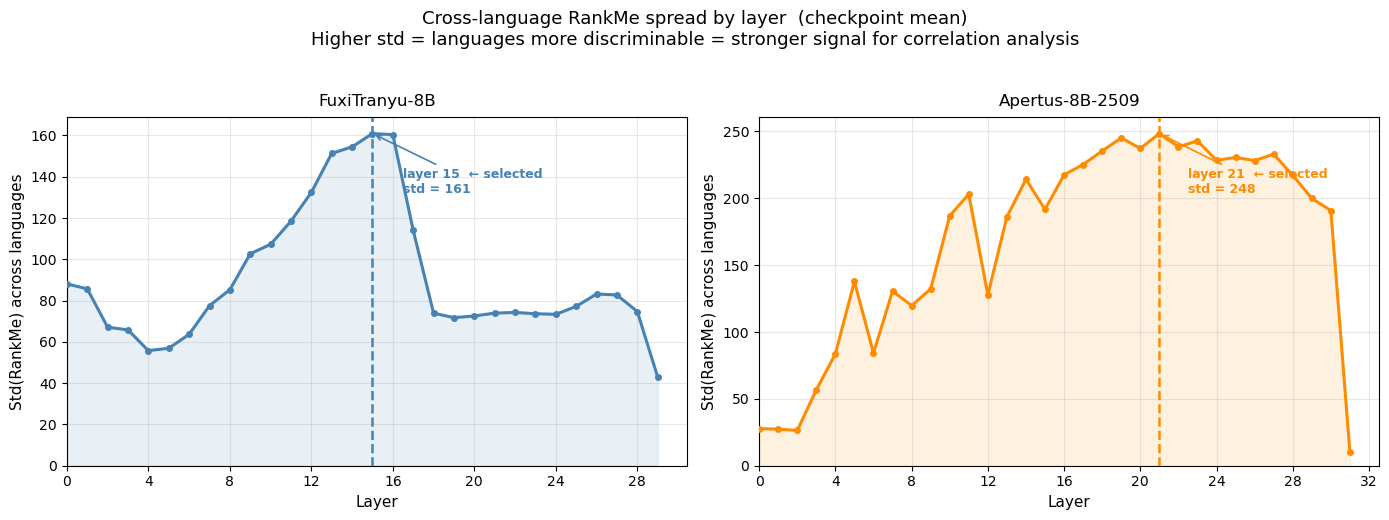

Saved: plots/layer_stratification.png


In [4]:
_strat_models = [
    dict(
        label     = data[m]["cfg"]["model_label"],
        csv       = data[m]["cfg"]["rankme_csv"],
        color     = data[m]["color"],
        model_key = m,
    )
    for m in MODELS
]
_fig = plot_stratification(_strat_models)
_fig.savefig(data[MODELS[0]]["cfg"]["plots_dir"] / "layer_stratification.png",
             dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/layer_stratification.png")

### Selected layers

- **FuxiTranyu-8B → layer 15** (std = 160.9): peak stratification in the mid-network, consistent with the mid-layer RankMe peak identified in the layer profile analysis. The signal drops sharply in deeper layers as language representations converge toward shared features.
- **Apertus-8B-2509 → layer 21** (std = 248.4): peak stratification in the upper-middle region of the network. The signal collapses steeply beyond this layer as representations reach a plateau where all languages look similar.

These are the layers used throughout this notebook for all correlation and per-checkpoint analyses.

## Data

Two separate sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_15` for FuxiTranyu-8B, `layer_21` for Apertus-8B-2509, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run. These layers were selected by the cross-language stratification analysis in the **Layer Selection** section above.

- **`fuxi_fine_wiki_layer15_merged.csv` / `apertus_fine_wiki_layer21_merged.csv`** — downstream accuracy merged with geometry metrics at the selected layer, produced by `merge_results.py --layer layer_15` / `--layer layer_21` after running evaluation on the cluster. Used for grokking detection, correlation analysis, and overlay plots.

In [5]:
for m in MODELS:
    cfg = data[m]["cfg"]
    df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(
        cfg["rankme_csv"], cfg["layer"], cfg["aggregation"])
    df_eval, eval_available = load_eval_data(cfg["merged_csv"])
    data[m].update({
        "df_rankme":       df_rankme,
        "df_layer":        df_layer,
        "checkpoints_all": checkpoints_all,
        "token_counts":    token_counts,
        "langs_sorted":    langs_sorted,
        "df_eval":         df_eval,
        "eval_available":  eval_available,
    })
    print()

Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_15, agg=last → 798 rows
Loaded eval: 741 records — 2 task(s), 57 checkpoint(s)

Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_21, agg=last → 616 rows
Loaded eval: 572 records — 2 task(s), 44 checkpoint(s)



## RankMe Trajectories

The table below summarises key geometry metrics per language, derived from the RankMe trajectory at the working layer:

- **peak (B)** — token count at the global RankMe maximum.
- **RankMe first ckpt** — representational richness at the first observed checkpoint.
- **RankMe valley / valley (B)** — bottom of the initial compression descent, detected with K=2 robustness.
- **Initial drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (valley_tokens − first_tokens).
- **RankMe last ckpt** — representational richness at the end of training.
- **mean early (0–25%)** — mean RankMe over checkpoints in the first 25% of the token range.
- **mean medium (0–50%)** — mean RankMe over checkpoints in the first 50% of the token range.
- **mean late (75–100%)** — mean RankMe over checkpoints in the last 25% of the token range.
- **mean before valley** — mean RankMe from the first checkpoint up to and including the valley.
- **mean after valley** — mean RankMe from the checkpoint after the valley to the last.

In [6]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_geometry = compute_geometry(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_geometry"] = df_geometry

    display_cols = {
        "language":                 "language",
        "peak_tokens":              "peak (B)",
        "rankme_first":             "RankMe first ckpt",
        "rankme_valley":            "RankMe valley",
        "valley_tokens":            "valley (B)",
        "rankme_initial_drop_rate": "initial drop rate (1/B)",
        "rankme_last":              "RankMe last ckpt",
        "rankme_early_mean":        "mean early (0–25%)",
        "rankme_medium_mean":       "mean medium (0–50%)",
        "rankme_late_mean":         "mean late (75–100%)",
        "rankme_before_valley":     "mean before valley",
        "rankme_after_valley":      "mean after valley",
    }
    print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
    print(df_geometry[list(display_cols)].rename(columns=display_cols).to_string(index=False))


── FuxiTranyu-8B ────────────────────────────────────────
  language  peak (B)  RankMe first ckpt  RankMe valley  valley (B)  initial drop rate (1/B)  RankMe last ckpt  mean early (0–25%)  mean medium (0–50%)  mean late (75–100%)  mean before valley  mean after valley
    Arabic      10.0           208.1951         6.2414        94.0                 2.404211          109.5834          121.725257           117.594629           109.692240          126.645133         112.620469
   Chinese      10.0           462.7990         4.9610        94.0                 5.450452          210.6758          241.225943           215.600786           215.763747          272.441522         202.379327
   English      10.0           679.2200        12.7191        94.0                 7.934535          364.2651          444.907657           406.503457           372.928493          480.588778         375.153850
   Finnish      10.0           545.0230         4.8511        94.0                 6.430618      

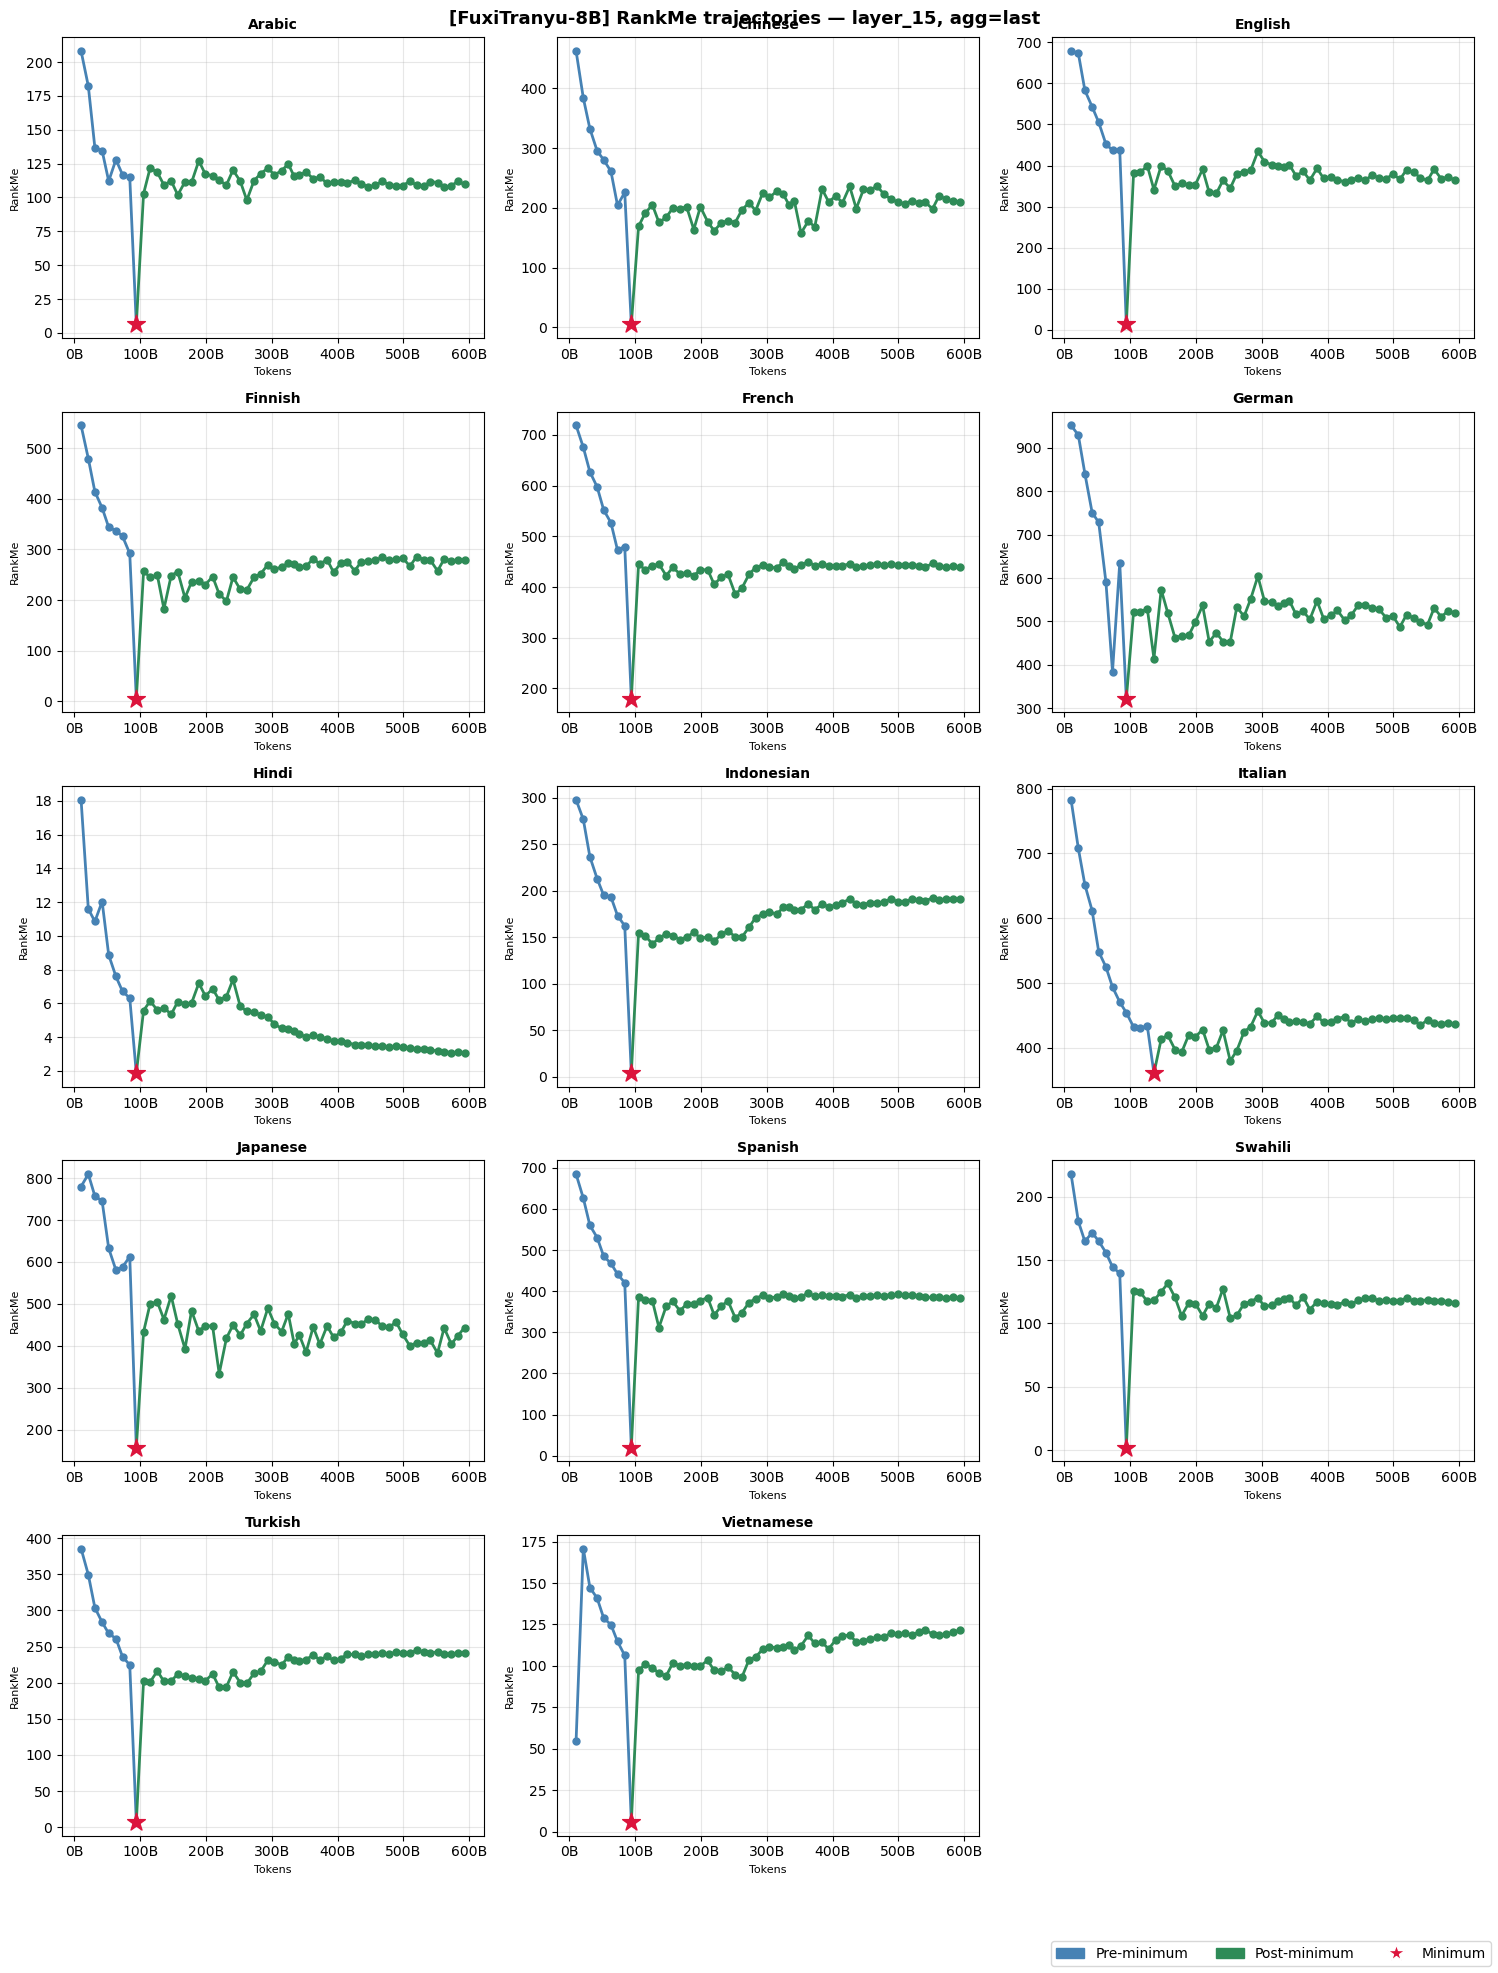

Saved: plots/rankme_phases_fuxi.png


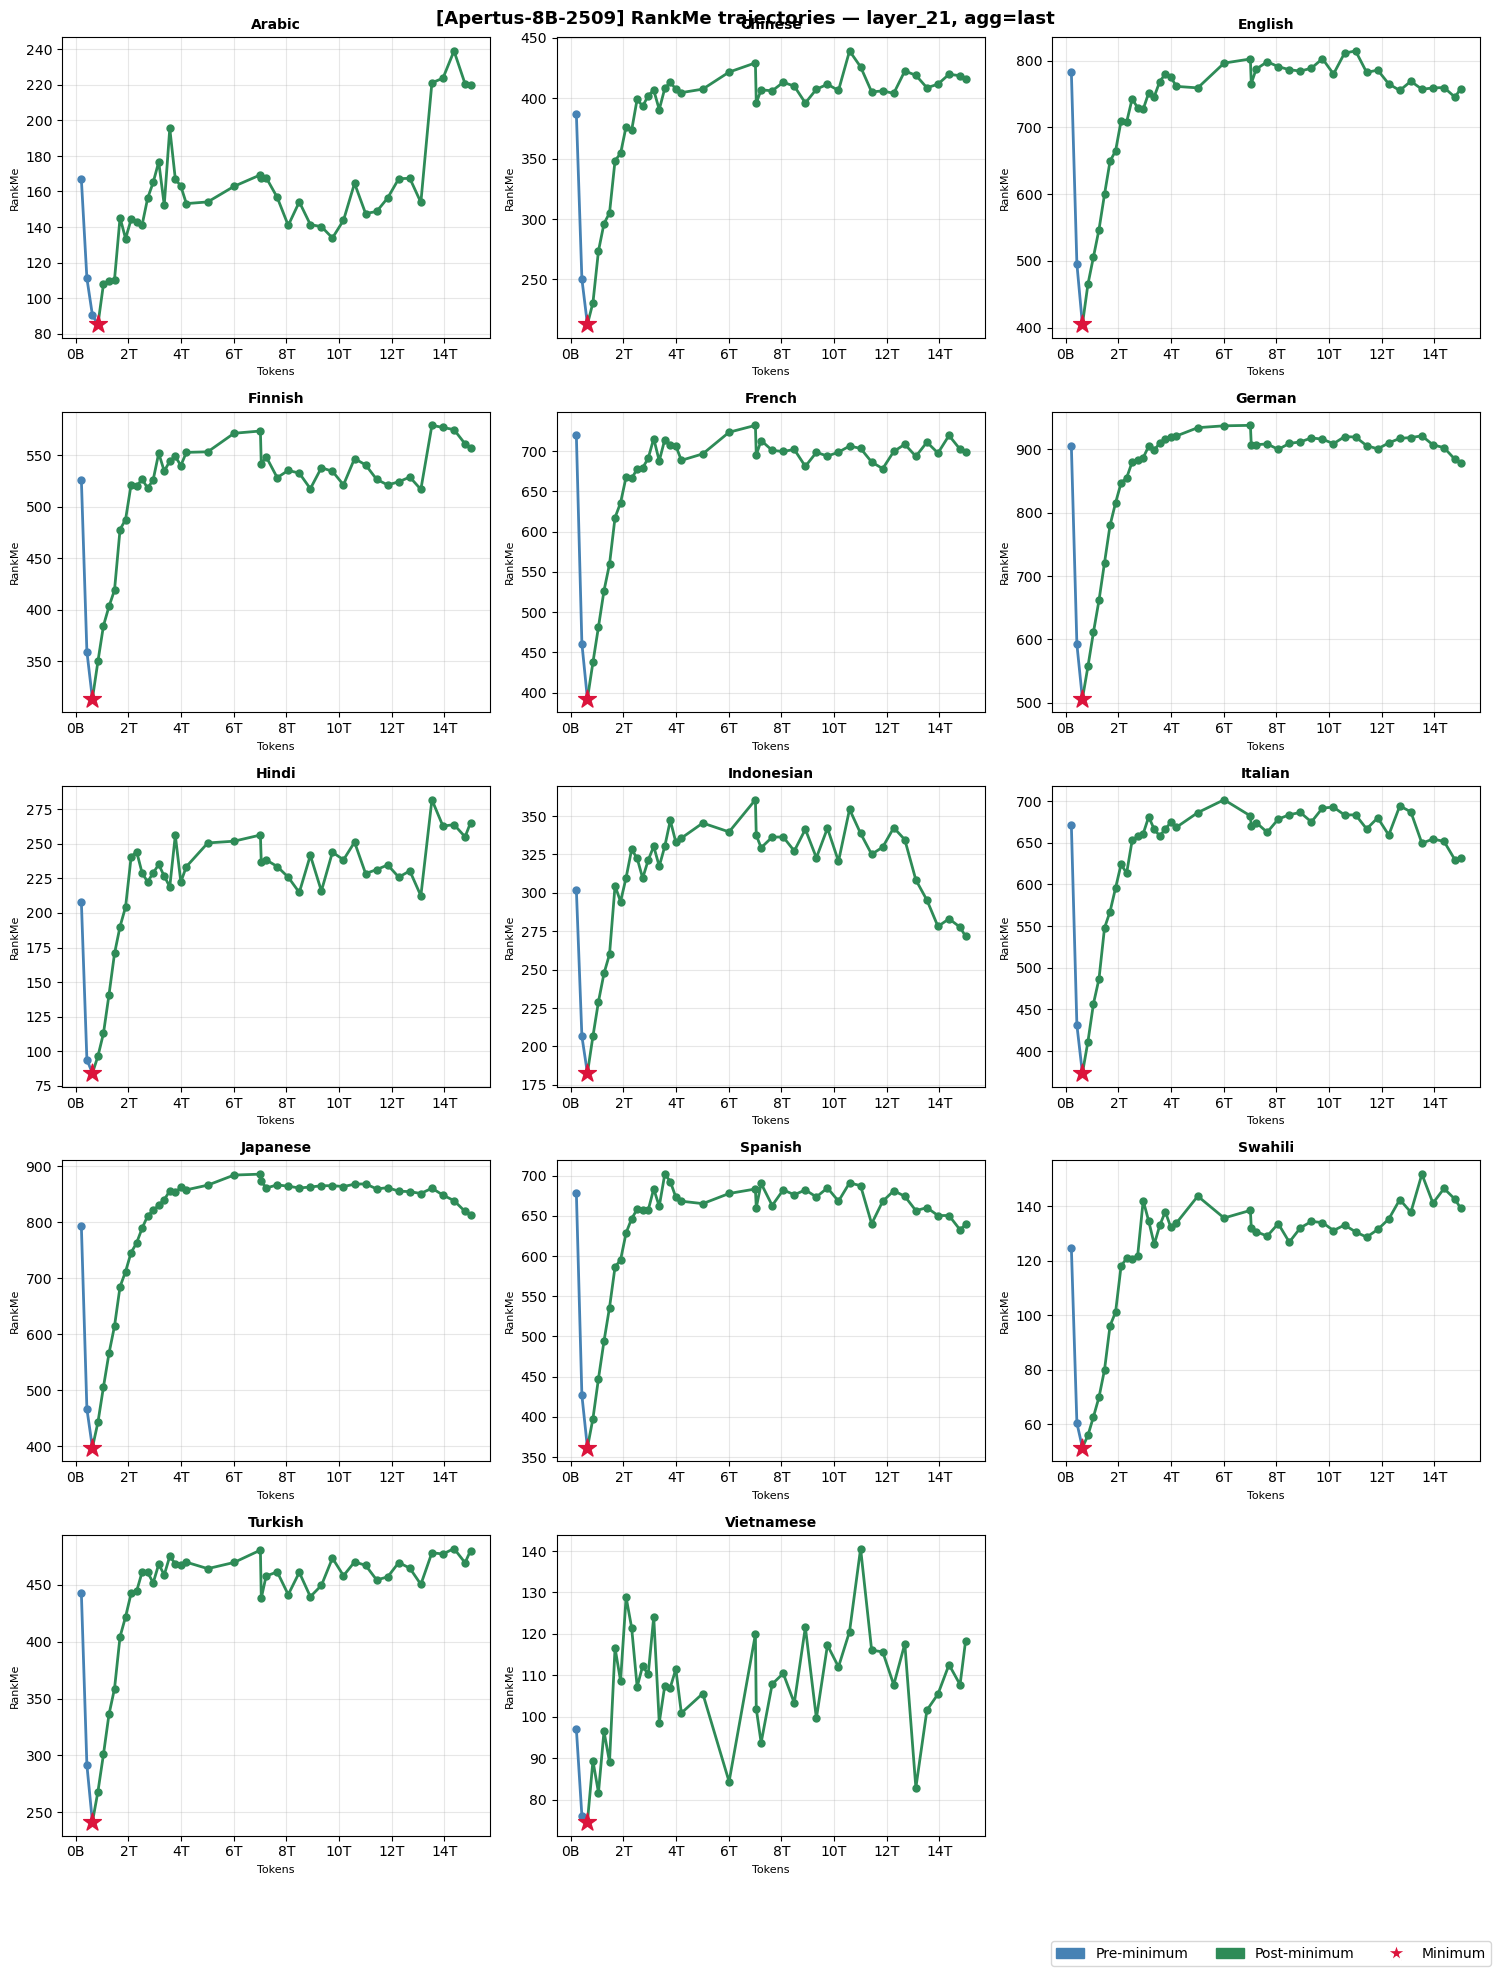

Saved: plots/rankme_phases_apertus.png


In [7]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    plot_rankme_phases(d["df_layer"], d["checkpoints_all"], d["token_counts"],
                       d["langs_sorted"], cfg["model_label"], cfg["layer"], cfg["aggregation"],
                       cfg["plots_dir"], model_key=m, df_geometry=d.get("df_geometry"))

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task:

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [8]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        df_grokking = compute_grokking(d["df_eval"], cfg["task_languages"], cfg["random_chance"],
                                       threshold=cfg["grokking_threshold"],
                                       min_consecutive=cfg["grokking_min_consec"])
        d["df_grokking"] = df_grokking
        display_cols = {
            "task":            "task",
            "language":        "language",
            "grokking_tokens": "grokking onset (B)",
            "peak_tokens":     "peak (B)",
            "peak_accuracy":   "peak accuracy",
            "random_chance":   "random chance",
        }
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
    else:
        d["df_grokking"] = pd.DataFrame()
        print(f"[{m}] No eval data — run submit_eval.sh + merge_results.py first.")


── FuxiTranyu-8B ────────────────────────────────────────
  task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
m_mmlu    English                 NaN     115.0       0.272590           0.25
m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
m_mmlu     German                 NaN     199.0       0.274928           0.25
m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
m_mmlu    Italian                 NaN     415.0       0.275818           0.25
m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
 xcopa    Chinese               325.0     426.0       0.664000           0.50
 xcopa    Italian               241.0     520.0       0.718000           0.50
 xcopa Vietnamese               126.0     436.0       0.736000           0.50
 xcop

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language. Each panel shows two y-axes:

- **Left axis** — RankMe trajectory split into two phases: **blue** = Pre-minimum, **green** = Post-minimum. A red star marks the minimum point.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — absent when grokking was not detected.

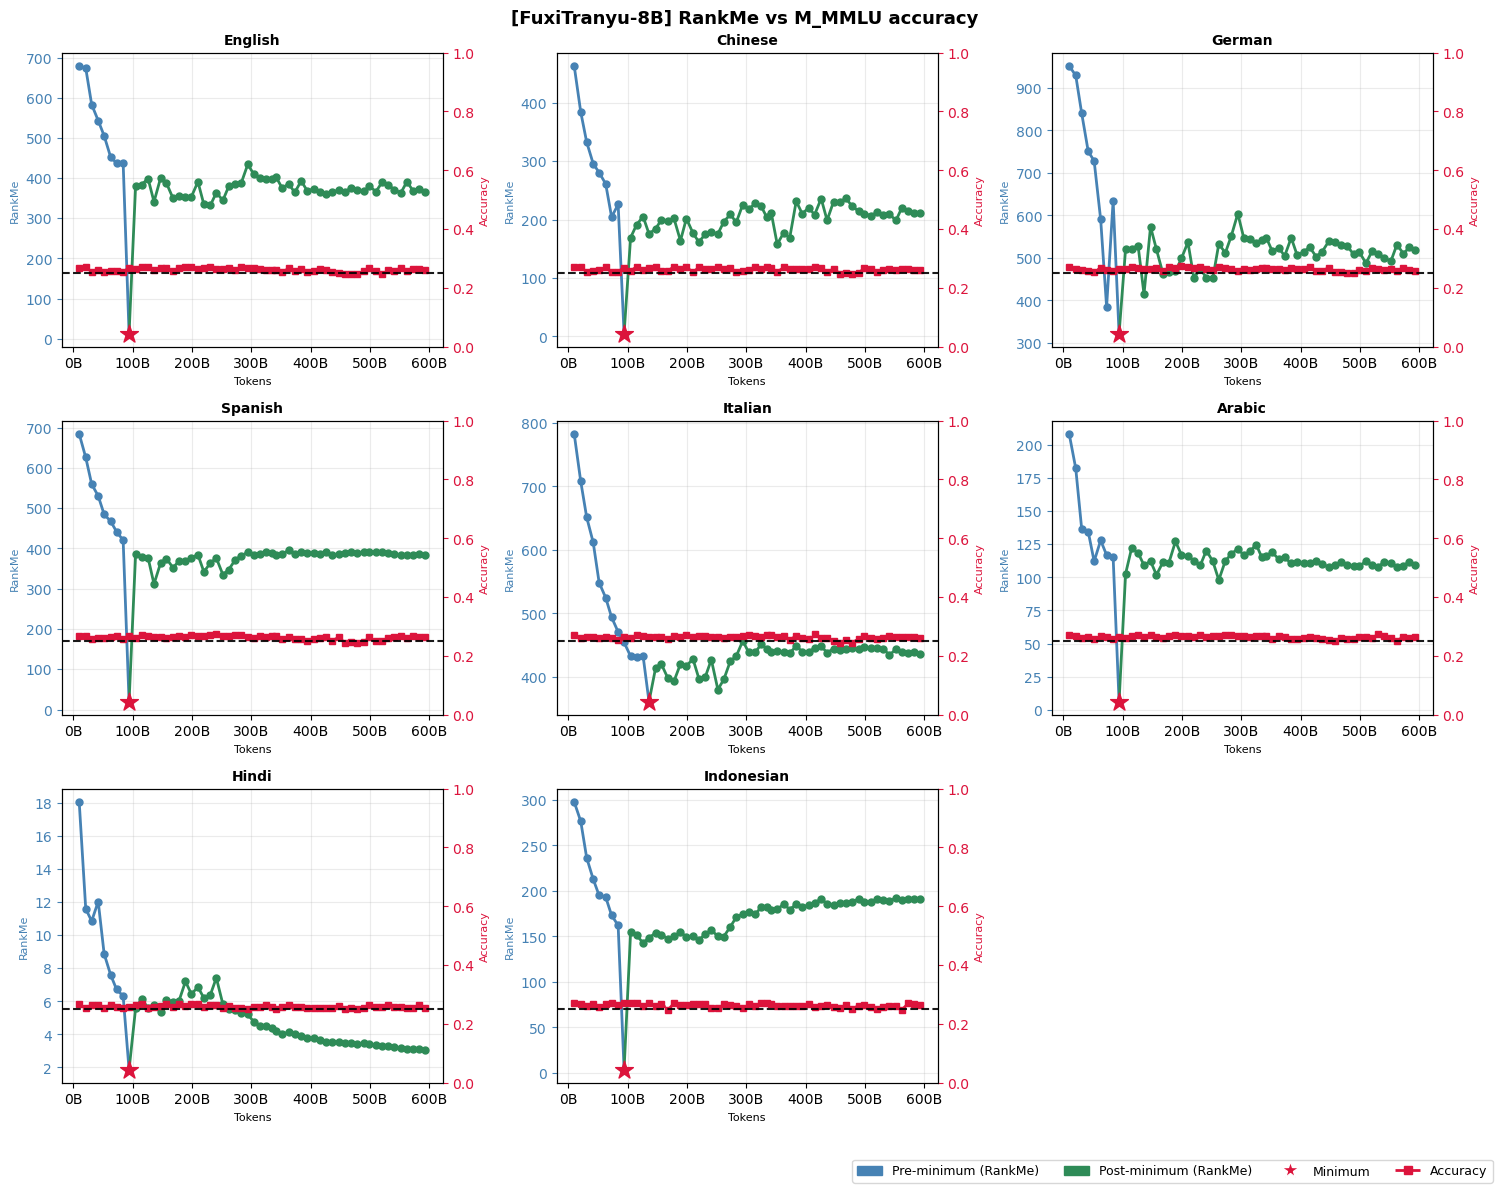

Saved: plots/overlay_m_mmlu_fuxi.png


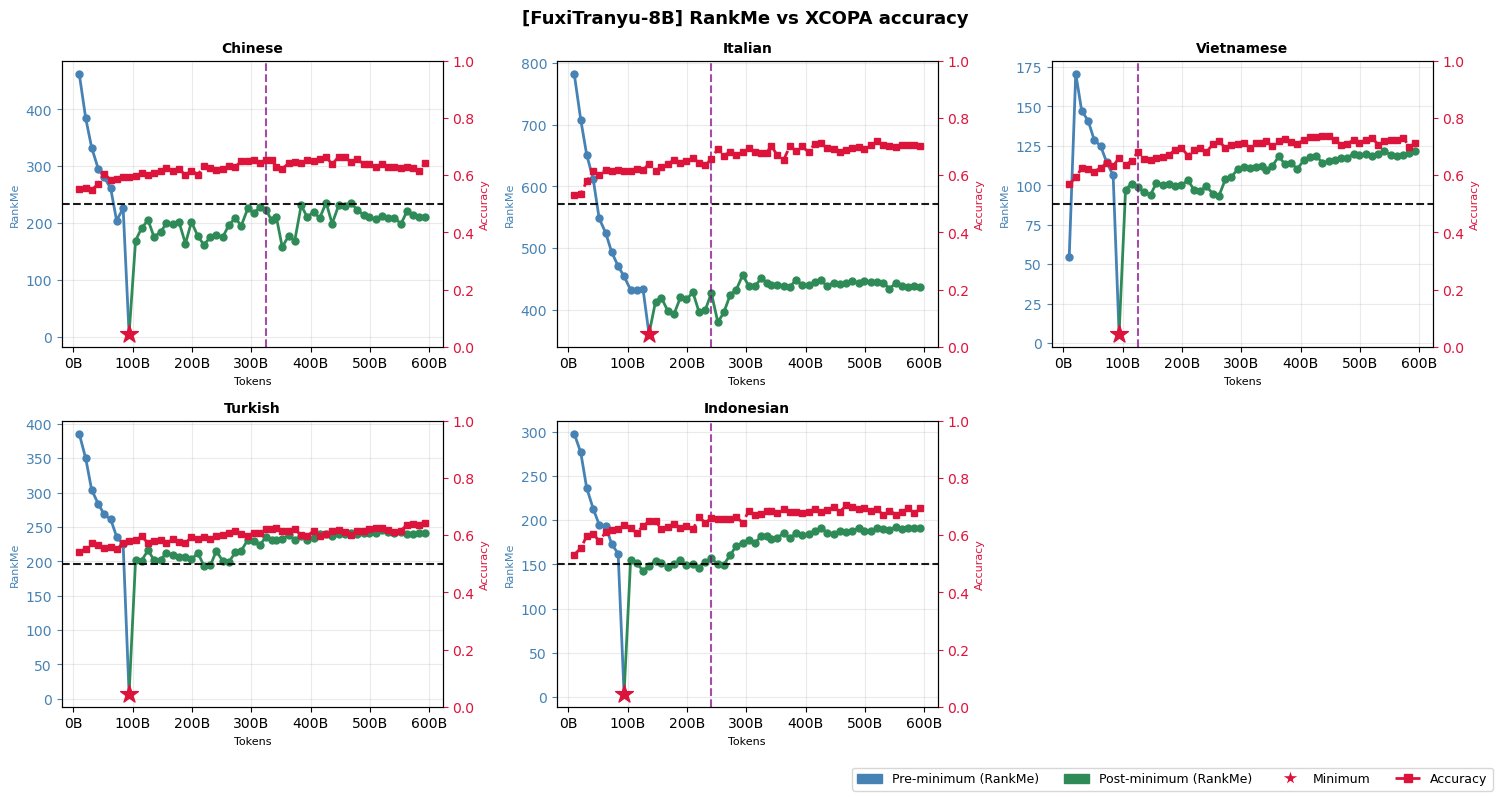

Saved: plots/overlay_xcopa_fuxi.png


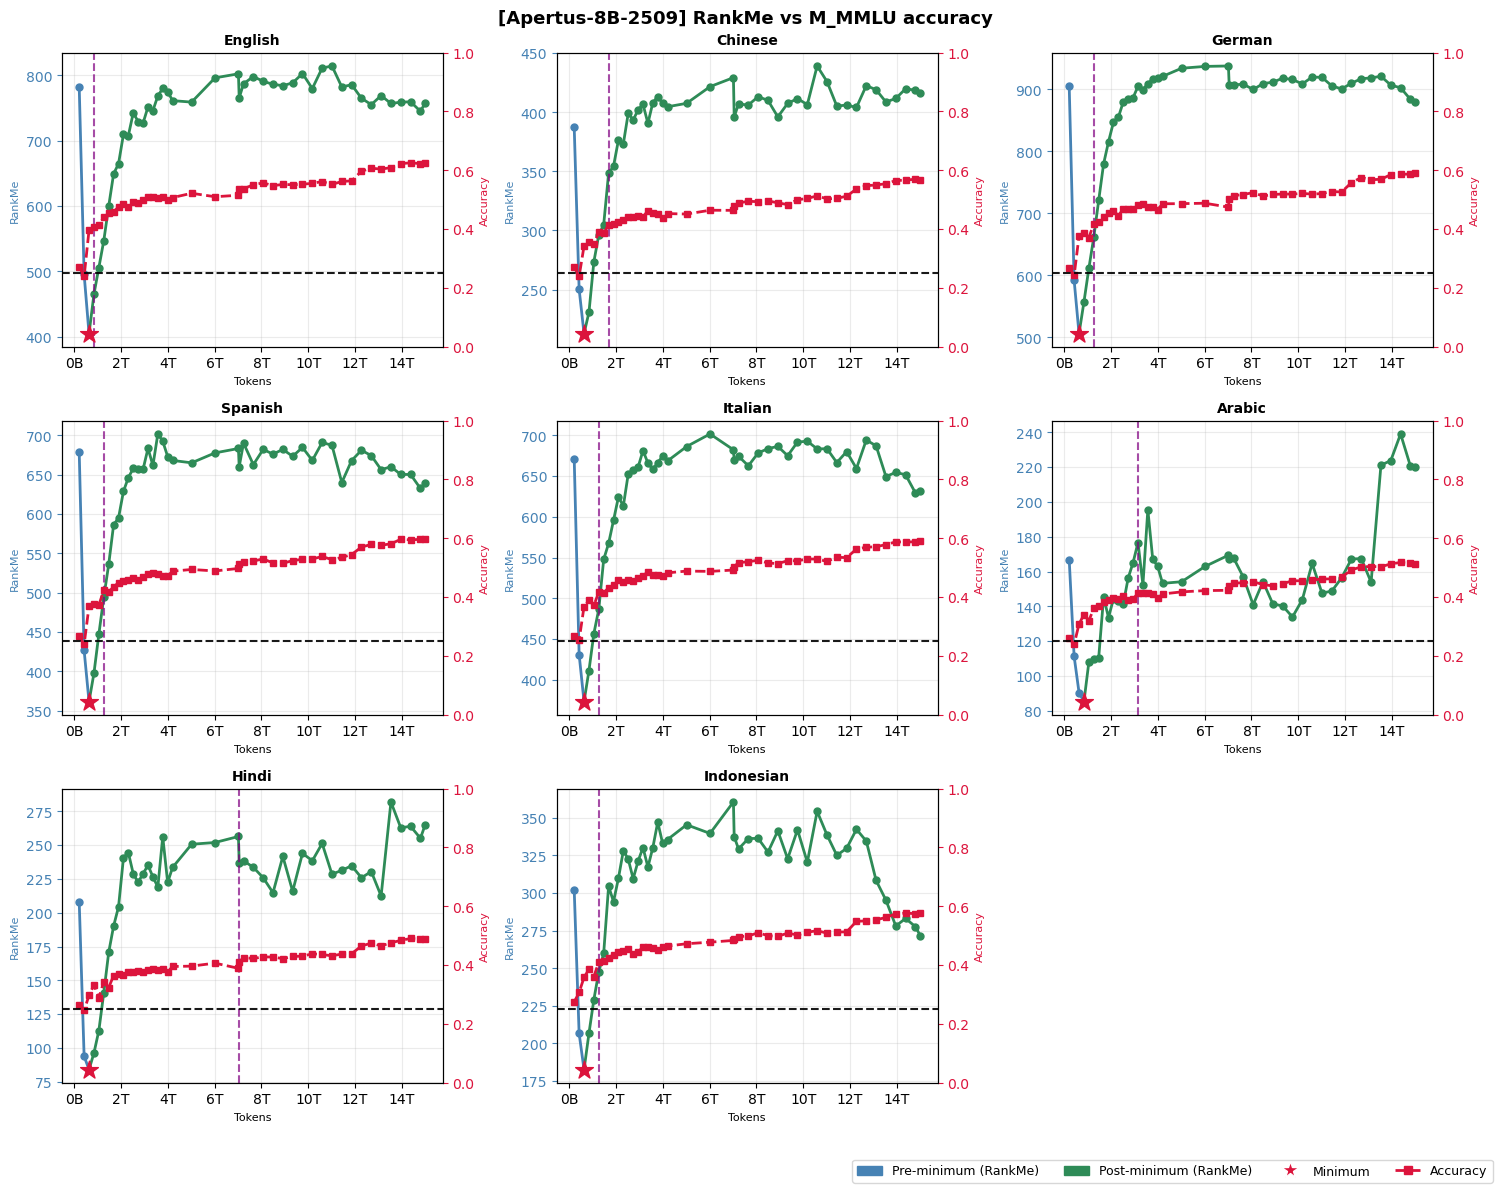

Saved: plots/overlay_m_mmlu_apertus.png


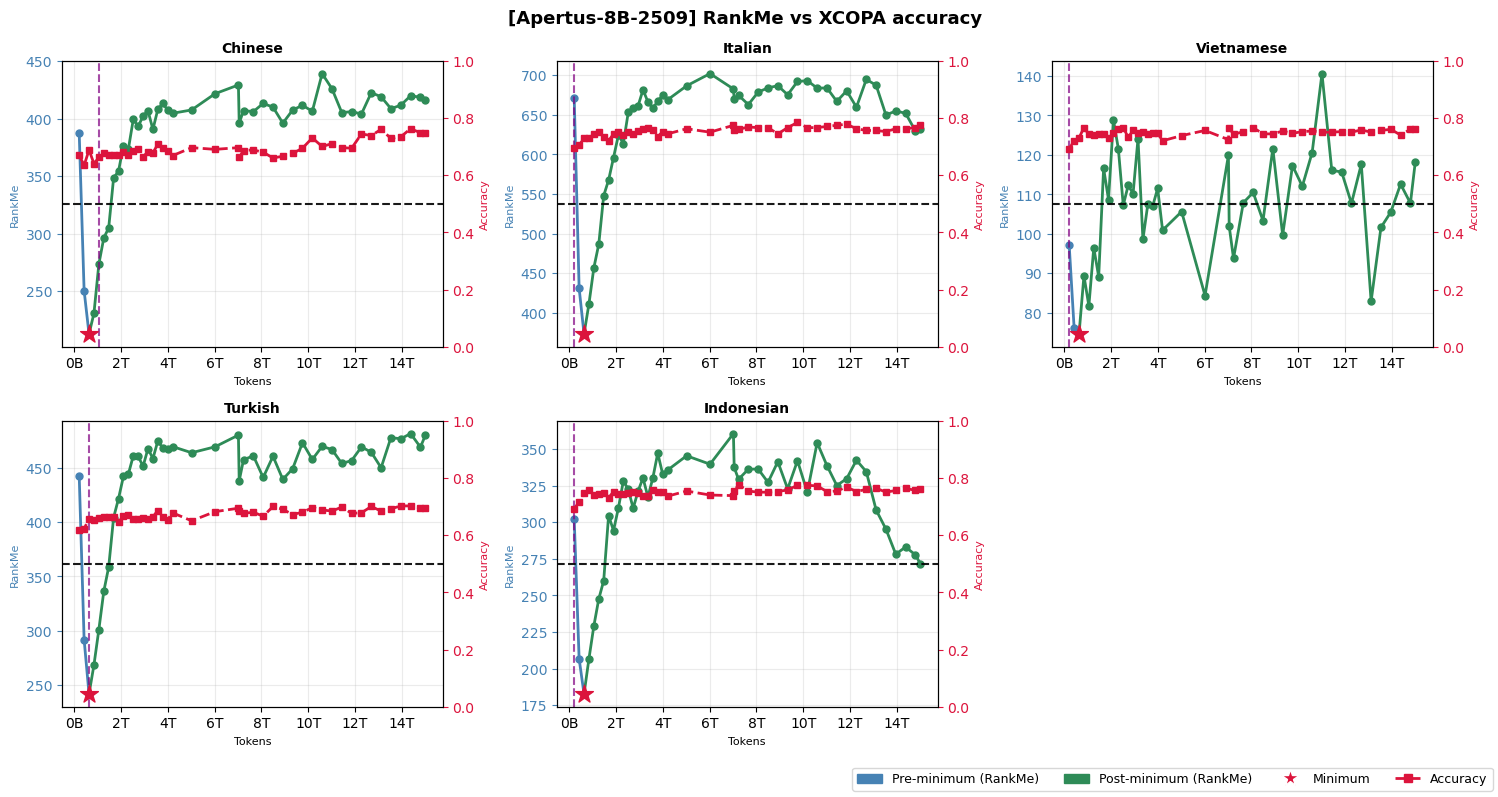

Saved: plots/overlay_xcopa_apertus.png


In [9]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        plot_overlay(d["df_eval"], d["df_layer"], d["df_grokking"],
                     cfg["task_languages"], cfg["random_chance"],
                     d["checkpoints_all"], d["token_counts"], d["langs_sorted"],
                     cfg["model_label"], cfg["plots_dir"], model_key=m,
                     df_geometry=d.get("df_geometry"))
    else:
        print(f"[{m}] Skipping overlay plots — run evaluate.py first.")

## Correlation Analysis

Tests whether RankMe geometry predicts downstream performance. Nine predictors are tested against two outcomes, separately per task:

**Point-in-time predictors**
- **RankMe at first ckpt** — representation richness at the start of training; the strongest single predictor for Apertus.
- **Valley of first descent (B)** — token count at the bottom of the initial compression drop.
- **Initial RankMe drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (tokens[valley] − tokens[first]); how steeply the model compresses each language's representations during the initial descent.
- **RankMe at last ckpt** — representation richness at the end of training.

**Trajectory-averaged predictors** (robust to single-checkpoint noise)
- **Mean RankMe — first 25% of tokens** — average over checkpoints in the first quarter of the token range.
- **Mean RankMe — first 50% of tokens** — average over checkpoints in the first half of the token range.
- **Mean RankMe — last 25% of tokens** — average over checkpoints in the last quarter of the token range.
- **Mean RankMe — before valley** — average over all checkpoints from start up to and including the valley.
- **Mean RankMe — after valley** — average over all checkpoints after the valley to the end of training.

Outcomes:
- **Grokking onset (B)** — when accuracy first crosses the threshold.
- **Peak accuracy** — highest accuracy across all checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [10]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_grokking"].empty:
        df_correlations = compute_correlations_table(d["df_grokking"], d["df_geometry"])
        d["df_correlations"] = df_correlations
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_correlations.to_string(index=False))
    else:
        d["df_correlations"] = pd.DataFrame()
        print(f"[{m}] Skipping correlation analysis — no eval data available.")


── FuxiTranyu-8B ────────────────────────────────────────
  task                     predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu              RankMe at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu              RankMe at first ckpt      Peak accuracy            8      0.6667      0.0710     0.7497     0.0322
m_mmlu       Valley of first descent (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu       Valley of first descent (B)      Peak accuracy            8      0.4124      0.3100     0.4156     0.3058
m_mmlu    Initial RankMe drop rate (1/B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu    Initial RankMe drop rate (1/B)      Peak accuracy            8      0.2143      0.6103     0.5573     0.1512
m_mmlu               RankMe at last ckpt Grokking onset (B)            0         NaN         NaN        NaN 

### Correlation Heatmap

The table above has 36 rows (9 predictors × 2 outcomes × 2 tasks). The heatmap below condenses all of them into a single 9×4 figure per model (rows = predictors, columns = tasks × outcomes). Colour encodes Spearman ρ; * marks p < 0.05; gray cells indicate undefined correlations (zero variance in the predictor — e.g. all Apertus languages share the same 630B valley timing for XCOPA).

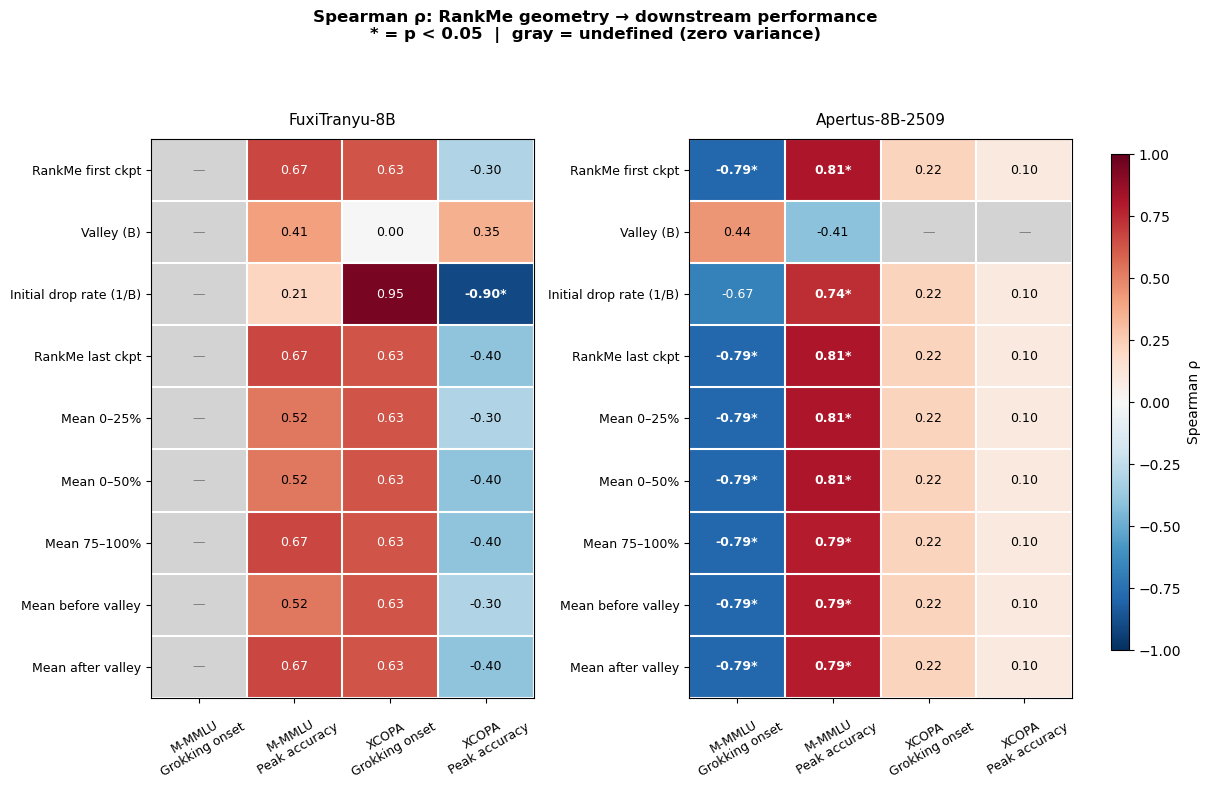

Saved: plots/correlation_heatmap.png


In [11]:
models_data = [
    {
        "label":           data[m]["cfg"]["model_label"],
        "df_grokking":     data[m].get("df_grokking", pd.DataFrame()),
        "df_geometry":     data[m].get("df_geometry", pd.DataFrame()),
        "df_correlations": data[m].get("df_correlations", pd.DataFrame()),
        "color":           data[m]["color"],
        "marker":          data[m]["marker"],
    }
    for m in MODELS if data[m]["eval_available"]
]

if models_data:
    plot_correlation_heatmap(models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping heatmap — no eval data available.")

### Selected Scatter Plots

Two predictors are highlighted for detailed scatter plots:

- **Initial RankMe drop rate** — the strongest XCOPA predictor for FuxiTranyu-8B (Sp r = +0.949 for grokking onset, Sp r = −0.900 for peak accuracy).
- **RankMe at first checkpoint** — the strongest m-MMLU predictor for Apertus-8B-2509 (Sp r = +0.810 for peak accuracy, Sp r = −0.786 for grokking onset).

Each 2×2 figure shows all four outcome × task combinations, with per-model regression lines and Spearman/Pearson statistics.

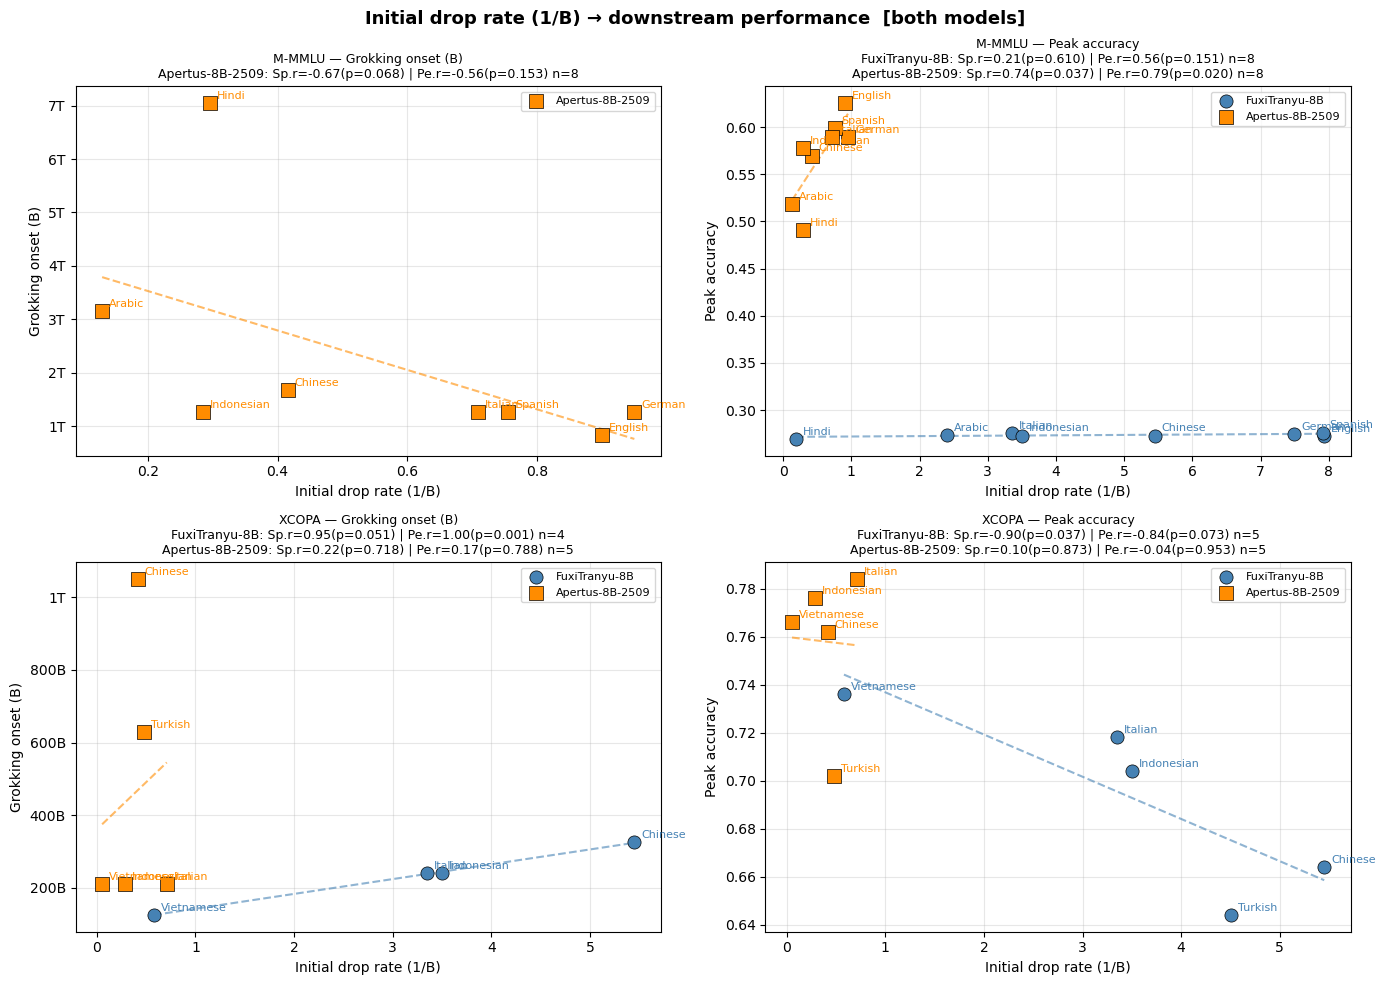

Saved: plots/scatter_rankme_initial_drop_rate.png


In [12]:
if models_data:
    plot_predictor_scatter(models_data, "rankme_initial_drop_rate",
                           "Initial drop rate (1/B)", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

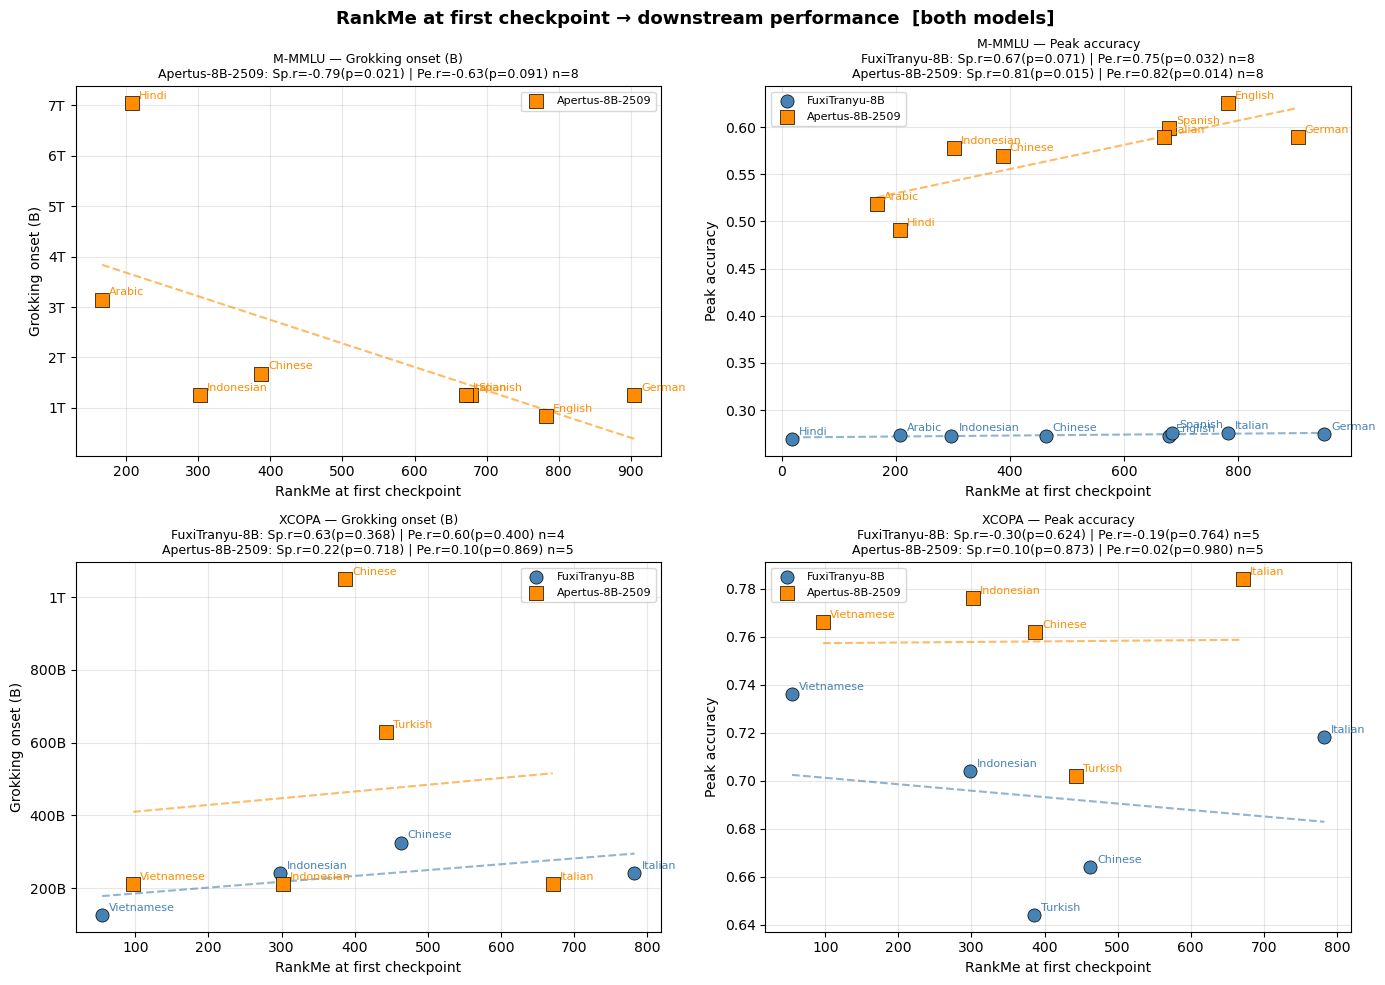

Saved: plots/scatter_rankme_first.png


In [13]:
if models_data:
    plot_predictor_scatter(models_data, "rankme_first",
                           "RankMe at first checkpoint", data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping scatter — no eval data available.")

## Predictor Analysis Findings

### FuxiTranyu-8B

**Phase structure (RankMe at layer 15, all 14 languages)**

- Layer 15 is the point of maximum cross-language RankMe spread (std = 160.9), capturing the mid-training representational peak before the sharp collapse documented in the layer profile analysis.
- RankMe magnitudes span nearly two orders of magnitude across languages: German (952), Italian (783), French (719), Spanish (684), English (679), Japanese (780) versus Hindi (18), Vietnamese (55), Swahili (218), Arabic (208). This spread reflects cross-lingual transfer capacity: high-resource, Latin-script and CJK languages build far richer representations at the mid-layer peak.
- 12 of 14 languages peak at the very first checkpoint (10B tokens); Japanese and Vietnamese peak at 21B. All 14 languages reach their valley at 94B (or 136B for Italian, whose descent is more gradual), after which representational richness partially recovers.

**m-MMLU knowledge accuracy (8 languages)**

- Accuracy remains at random chance (~25%) for all 8 languages across all 57 checkpoints. No grokking is detected: factual knowledge retrieval does not emerge during pre-training for FuxiTranyu-8B at this scale.
- Despite the absence of grokking, the large cross-language RankMe spread at layer 15 reveals a significant linear relationship between representational richness and peak m-MMLU accuracy. Every richness predictor yields a significant Pearson correlation with peak accuracy:

| Predictor | Pearson r | p |
|---|---|---|
| RankMe at last ckpt | +0.773 | 0.024 |
| Mean late (75–100%) | +0.771 | 0.025 |
| Mean after valley | +0.762 | 0.028 |
| RankMe at first ckpt | +0.750 | 0.032 |
| Mean medium (0–50%) | +0.747 | 0.033 |
| Mean early (0–25%) | +0.740 | 0.036 |
| Mean before valley | +0.728 | 0.041 |

- The Spearman correlations are borderline (Sp r = +0.667, p = 0.071 for point-in-time predictors; Sp r = +0.524, p = 0.183 for trajectory means), indicating the relationship is driven by the magnitude ordering of a few very high-resource languages rather than a clean rank-monotone trend across all 8.
- Valley timing and initial drop rate do not significantly predict m-MMLU outcomes (both p > 0.15): for m-MMLU, *how much* representational richness a language retains matters, not *how fast* it was compressed.

**XCOPA commonsense accuracy (5 languages)**

- Grokking is detected in 4 of 5 languages: Vietnamese (126B), Italian and Indonesian (241B), Chinese (325B). Turkish never reaches the 15 pp threshold above chance (peak 0.644).
- Performance ranking: Vietnamese (0.736) > Italian (0.718) > Indonesian (0.704) > Chinese (0.664) > Turkish (0.644). Latin-script languages outperform, consistent with cross-lingual transfer from English-dominated pre-training data.
- **The initial RankMe drop rate is the strongest predictor of XCOPA outcomes — a finding enabled by the corrected valley detection:**
  - → Grokking onset (n=4): **Pearson r = +0.9995, p = 0.0005; Sp r = +0.949, p = 0.051**. The four languages that grokked fall almost perfectly on a line: higher drop rate → later grokking onset.
  - → Peak accuracy (n=5): **Sp r = −0.900, p = 0.037** (statistically significant); Pearson r = −0.842, p = 0.074. Languages that compress more steeply achieve lower XCOPA accuracy.
- The ordering is exact: Vietnamese has the lowest drop rate (0.58/B, first checkpoint only 54.5 at layer 15) and the earliest grokking and highest accuracy; Chinese has the highest drop rate (5.45/B) and the latest grokking and second-lowest accuracy; Turkish (drop rate 4.51/B, never grokked) fits the pattern.
- **Interpretation:** The rate at which a language's mid-layer representations are compressed during the initial descent is a direct predictor of commonsense reasoning emergence. Languages that shed representational richness slowly retain more multilingual structure through the compression phase, enabling earlier and stronger XCOPA generalisation. This is a qualitatively different signal from the richness-level predictors that matter for m-MMLU: for XCOPA it is the *dynamics* of compression, not the absolute level, that predicts outcomes.
- No other predictor is significant for XCOPA (all Spearman p > 0.37).

---

### Apertus-8B-2509

**Phase structure (RankMe at layer 21, all 14 languages)**

- Layer 21 is the point of maximum cross-language RankMe spread (std = 248.4), located in the upper-middle of the monotone rise just before the plateau documented in the layer profile analysis.
- RankMe magnitudes span a wide range: German (905), Japanese (793), English (783), French (720), Spanish (679), Italian (671), Finnish (526), Turkish (443), Indonesian (302), Hindi (208), Arabic (167), Swahili (125), Vietnamese (97). The language hierarchy closely mirrors script familiarity and pre-training data volume.
- All 14 languages show a clear initial compression valley at 630B (840B for Arabic), after which the model re-enters an entropy-seeking phase where RankMe rises again. The global peak occurs late in training (3 570B for Spanish up to 14 372B for Arabic and Turkish).

**m-MMLU knowledge accuracy (8 languages) — strong findings**

- Apertus grokked on m-MMLU for all 8 evaluated languages. Grokking onset spans 840B (English, earliest) to 7 047B (Hindi, latest). Peak accuracy spans 0.491 (Hindi) to 0.625 (English).
- **Every RankMe predictor has a significant Spearman correlation with grokking onset (all Sp r ≈ −0.786, p = 0.021, n = 8):** languages with higher layer-21 representational richness grok earlier, regardless of how richness is measured. Pearson correlations for grokking onset do not reach significance (all p > 0.07), indicating a rank-monotone but non-linear relationship.
- **Every RankMe predictor also has a significant Spearman correlation with peak m-MMLU accuracy (Sp r = +0.786–0.810, p = 0.015–0.021, n = 8).** The strongest Pearson correlations are:

| Predictor | Pearson r | p |
|---|---|---|
| Mean before valley | +0.828 | 0.011 |
| Mean early (0–25%) | +0.817 | 0.013 |
| RankMe at first ckpt | +0.815 | 0.014 |
| Mean medium (0–50%) | +0.815 | 0.014 |
| Mean after valley | +0.811 | 0.015 |
| Mean late (75–100%) | +0.793 | 0.019 |
| Initial drop rate (1/B) | +0.789 | 0.020 |
| RankMe at last ckpt | +0.769 | 0.026 |

- Valley timing (`valley_tokens`) is the only predictor that does not reach significance for either outcome (Sp r = +0.439, p = 0.276): when the initial compression occurs is less informative than how rich representations are at that layer.
- **Interpretation:** At layer 21, RankMe is a proxy for the total multilingual signal absorbed by each language at peak representational differentiation. Languages with richer mid-layer representations (high-resource, familiar-script) both reach knowledge grokking earlier and achieve higher factual accuracy. The signal is robust across all predictors; trajectory-averaged means add marginal noise reduction over single-checkpoint values.

**XCOPA commonsense accuracy (5 languages)**

- All 5 evaluated languages grok on XCOPA. Grokking onset: Italian, Indonesian, Vietnamese (210B); Turkish (630B); Chinese (1 050B). Peak accuracy: Italian (0.784), Vietnamese (0.766), Indonesian (0.776), Chinese (0.762), Turkish (0.702).
- All valley-based predictors have undefined variance for XCOPA (all 5 languages share the same 630B valley, giving zero variance in valley timing), so valley-derived correlations cannot be computed.
- No predictor is significant for XCOPA outcomes (all Spearman p > 0.70). The geometry at layer 21 does not predict commonsense reasoning performance for Apertus, consistent with XCOPA being driven by broad multilingual exposure rather than fine-grained representational differentiation at this layer.

## Per-Checkpoint Cross-Language Correlation

The previous predictor analysis tested whether a single geometry metric (computed from the full RankMe trajectory) predicts a language's final downstream outcome. Here we ask a complementary question: **at each training checkpoint, does the cross-language ranking of RankMe match the cross-language ranking of accuracy at that same checkpoint?**

### What we have at each checkpoint

At any given checkpoint (say, 241B tokens), we have two values per language:
- **RankMe(language)** — representational richness at that checkpoint
- **accuracy(language, task)** — the model's accuracy on that task at that same checkpoint

So at checkpoint 241B we have (for Apertus, m-MMLU):

| Language | RankMe @ 241B | m-MMLU accuracy @ 241B |
|----------|:-------------:|:----------------------:|
| English  | 620           | 0.41                   |
| German   | 780           | 0.38                   |
| Spanish  | 540           | 0.39                   |
| Hindi    | 160           | 0.27                   |
| ...      | ...           | ...                    |

We compute **one Spearman correlation** across these 8 rows. That gives us one number: ρ(241B) = how well the language ranking by RankMe matches the language ranking by accuracy at that moment.

### Repeat for every checkpoint → a curve

Do this at every checkpoint: 10B, 21B, 31B, …, 15000B. You get a sequence:

> ρ(10B), ρ(21B), ρ(31B), …, ρ(15000B)

Plotting this as a line over training answers: **as training progresses, does the model's geometry become a better or worse predictor of which languages it handles best?**

- A **positive ρ** means languages with higher RankMe also have higher accuracy at that moment.
- A **near-zero ρ** means the two rankings are unrelated — the geometry has no predictive power at that checkpoint.
- **Filled markers** = p < 0.05 (statistically significant); **open markers** = p ≥ 0.05.

In [14]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        df_ckpt_corr = compute_checkpoint_correlations(
            d["df_layer"], d["df_eval"],
            d["checkpoints_all"], d["token_counts"],
            cfg["task_languages"],
        )
        d["df_ckpt_corr"] = df_ckpt_corr
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        for task in ["m_mmlu", "xcopa"]:
            df_t = df_ckpt_corr[df_ckpt_corr["task"] == task]
            valid = df_t.dropna(subset=["spearman_r"])
            sig   = valid[valid["spearman_p"] < 0.05]
            print(f"  {task}: {len(sig)}/{len(valid)} checkpoints with p<0.05 | "
                  f"max ρ = {valid['spearman_r'].max():.3f} | "
                  f"min ρ = {valid['spearman_r'].min():.3f}")
    else:
        d["df_ckpt_corr"] = pd.DataFrame()
        print(f"[{m}] No eval data.")


── FuxiTranyu-8B ────────────────────────────────────────
  m_mmlu: 3/57 checkpoints with p<0.05 | max ρ = 0.762 | min ρ = -0.524
  xcopa: 1/57 checkpoints with p<0.05 | max ρ = 0.100 | min ρ = -0.900

── Apertus-8B-2509 ────────────────────────────────────────
  m_mmlu: 40/44 checkpoints with p<0.05 | max ρ = 0.952 | min ρ = 0.048
  xcopa: 0/44 checkpoints with p<0.05 | max ρ = 0.200 | min ρ = -0.700


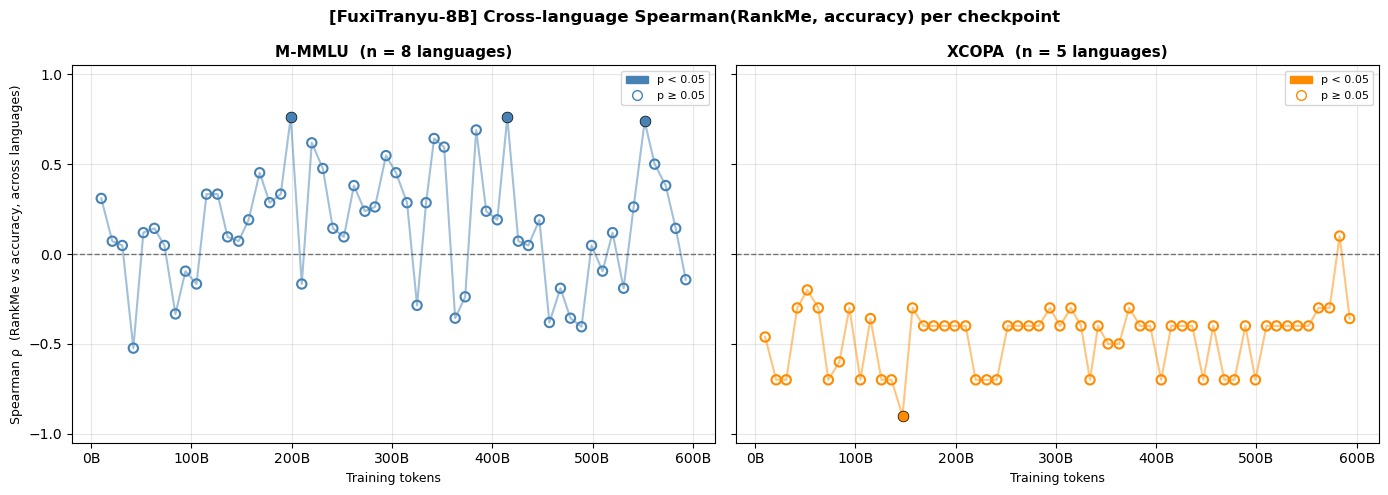

Saved: plots/checkpoint_correlations_fuxi.png


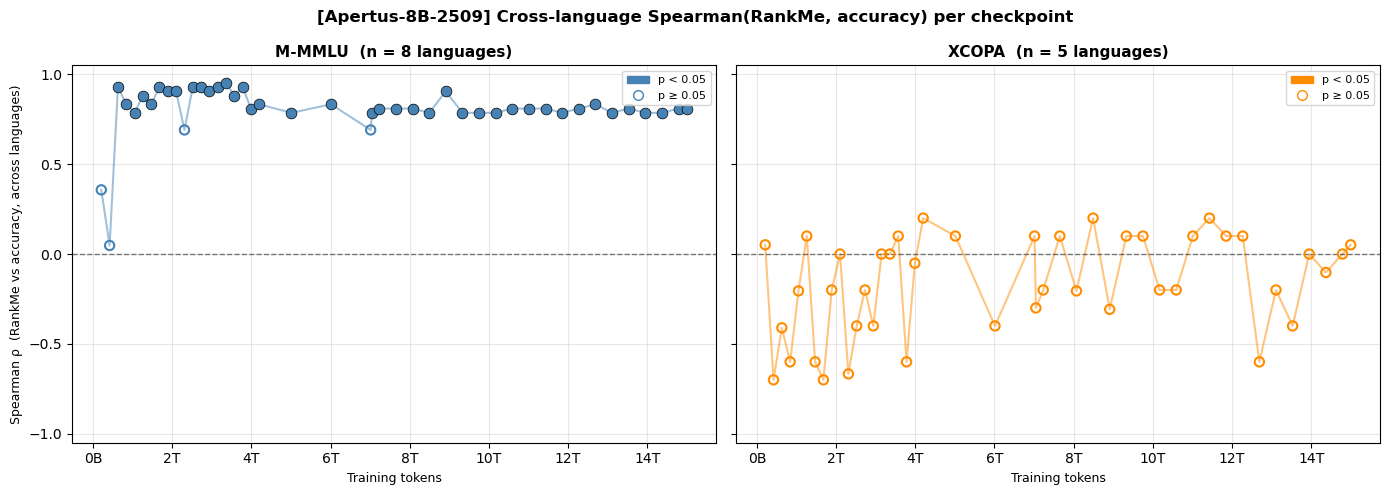

Saved: plots/checkpoint_correlations_apertus.png


In [15]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_ckpt_corr"].empty:
        plot_checkpoint_correlations(
            d["df_ckpt_corr"], cfg["model_label"], cfg["plots_dir"], model_key=m
        )

## Per-Checkpoint Correlation Findings

### FuxiTranyu-8B

**m-MMLU (8 languages): 3/57 checkpoints significant, max ρ = 0.762**

Near-zero live correlation throughout training, as expected. All 8 languages sit at ~25% accuracy (random chance) across all checkpoints, leaving essentially no variance in accuracy to correlate with RankMe. The 3 significant checkpoints are likely noise. The geometry carries no live predictive signal for factual knowledge when the model has not grokked at all.

**XCOPA (5 languages): 1/57 checkpoints significant, min ρ = −0.900**

The minimum ρ = −0.900 is the key result here: at some checkpoint, the cross-language RankMe ranking is strongly *inversely* correlated with XCOPA accuracy. This is not noise — it is fully consistent with the predictor analysis. Vietnamese has the lowest layer-15 RankMe (54.5 at the first checkpoint) but the best XCOPA performance (0.736) and earliest grokking (126B). Chinese has one of the highest RankMes and worse XCOPA. The geometry for Fuxi XCOPA runs in the **opposite direction** to what it does for m-MMLU: lower initial representational richness → lower compression rate → earlier and stronger commonsense reasoning emergence. The live correlation corroborates the drop-rate finding from a different angle.

---

### Apertus-8B-2509

**m-MMLU (8 languages): 40/44 checkpoints significant, max ρ = 0.952**

This is the strongest result in the notebook. Throughout 91% of training, the ranking of languages by RankMe at layer 21 matches their ranking by live m-MMLU accuracy at that same checkpoint. The geometry is not just a retrospective predictor of final outcomes — it is a **real-time tracker of the language performance hierarchy** from early in training. The few non-significant checkpoints correspond to the very earliest stages before any meaningful grokking has occurred (min ρ = 0.048 reflects near-random accuracy across all languages). Once grokking begins, the geometry locks into the performance ranking and maintains it almost perfectly for the rest of training. A single RankMe measurement at layer 21 at any checkpoint during training would let you predict which language the model handles best — without running any downstream evaluation.

**XCOPA (5 languages): 0/44 checkpoints significant, max ρ = 0.200**

No significant live correlation at any checkpoint. The geometry never tracks the XCOPA performance hierarchy across languages. This is consistent with the predictor analysis: XCOPA outcomes for Apertus are tightly clustered (0.702–0.784) and driven by broad multilingual exposure, not fine-grained representational differentiation at layer 21. The min ρ = −0.700 at some early checkpoint suggests that before grokking the geometry is briefly anti-aligned with XCOPA — possibly because the initial valley at 630B compresses all languages equally, temporarily disrupting any ordering — but the effect is not sustained and never reaches significance.